In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### Defin Dataset Path

In [3]:
DATASET_PATH = r"C:\Brain_Tumor\Epic and CSCR hospital Dataset"

CLASSES = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

IMG_SIZE = 224

### Tumor Masking Function

In [4]:
def mask_image(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray,(5,5),0)

    _,thresh = cv2.threshold(blur,45,255,cv2.THRESH_BINARY)

    masked = cv2.bitwise_and(img,img,mask=thresh)

    return masked

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

### Load Dataset

In [6]:
data = []
labels = []

train_path = os.path.join(DATASET_PATH, "Train")

for class_name in CLASSES:

    folder = os.path.join(train_path, class_name)

    if not os.path.isdir(folder):
        print(f"Warning: missing folder {folder}")
        continue

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: failed to read {img_path}")
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = mask_image(img)
        img = img.astype(np.float32) / 255.0

        data.append(img)
        labels.append(class_name)


data = np.array(data)
labels = np.array(labels)

### Convert Labels to Numeric

In [7]:
label_dict={
"glioma":0,
"meningioma":1,
"pituitary":2,
"notumor":3
}

labels=np.array([label_dict[i] for i in labels])

### Train Test Split

In [8]:
# Ensure the splitter is available (useful if this cell is run in isolation)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

### Data Augmentation

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(
rotation_range=20,
zoom_range=0.2,
horizontal_flip=True,
width_shift_range=0.1,
height_shift_range=0.1
)

datagen.fit(X_train)

NameError: name 'history' is not defined

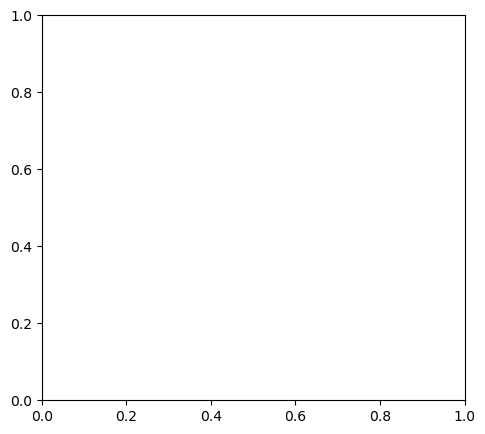

In [ ]:
if 'history' in globals():
	plt.figure(figsize=(12,5))

	plt.subplot(1, 2, 1)
	plt.plot(history.history['accuracy'], label='Train')
	plt.plot(history.history['val_accuracy'], label='Val')
	plt.title("Accuracy")
	plt.xlabel("Epoch")
	plt.ylabel("Accuracy")
	plt.legend()

	plt.subplot(1, 2, 2)
	plt.plot(history.history['loss'], label='Train')
	plt.plot(history.history['val_loss'], label='Val')
	plt.title("Loss")
	plt.xlabel("Epoch")
	plt.ylabel("Loss")
	plt.legend()

	plt.tight_layout()
	plt.show()
else:
	print("Run the training cell (index 23) first to define 'history'.")

### Load DenseNet 121

In [ ]:
from tensorflow.keras.applications import DenseNet121

base_model=DenseNet121(
weights='imagenet',
include_top=False,
input_shape=(224,224,3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable=False

### Build Classification Model


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x=base_model.output

x=GlobalAveragePooling2D()(x)

x=Dense(256,activation='relu')(x)

x=Dropout(0.5)(x)

predictions=Dense(4,activation='softmax')(x)

model=Model(inputs=base_model.input,outputs=predictions)

### Compile Model

In [ ]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

### Train Model

In [ ]:
history=model.fit(
datagen.flow(X_train,y_train,batch_size=32),
validation_data=(X_test,y_test),
epochs=20
)

Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.7073 - loss: 0.7658 - val_accuracy: 0.7575 - val_loss: 0.6016
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 415s 2s/step - accuracy: 0.7882 - loss: 0.5756 - val_accuracy: 0.7969 - val_loss: 0.5285
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 605s 3s/step - accuracy: 0.8095 - loss: 0.5083 - val_accuracy: 0.8539 - val_loss: 0.4026
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 627s 3s/step - accuracy: 0.8272 - loss: 0.4595 - val_accuracy: 0.8720 - val_loss: 0.3423
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 635s 3s/step - accuracy: 0.8330 - loss: 0.4586 - val_accuracy: 0.8694 - val_loss: 0.3436
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 653s 3s/step - accuracy: 0.8396 - loss: 0.4263 - val_accuracy: 0.8891 - val_loss: 0.3126
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 630s 3s/step - accuracy: 0.8497 - loss: 0.4031 - val_accuracy: 0.8130 - val_loss: 0.4823
Epoch 8/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 639s 3s/step - accuracy: 0.8487 - loss: 0.4096 - val_accu

### Accuracy Graph

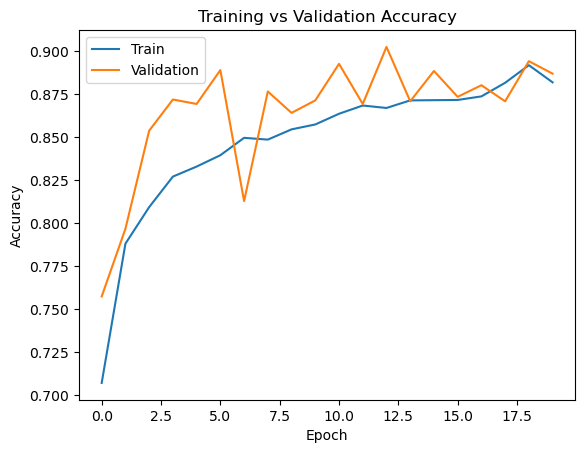

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

### Loss Graph

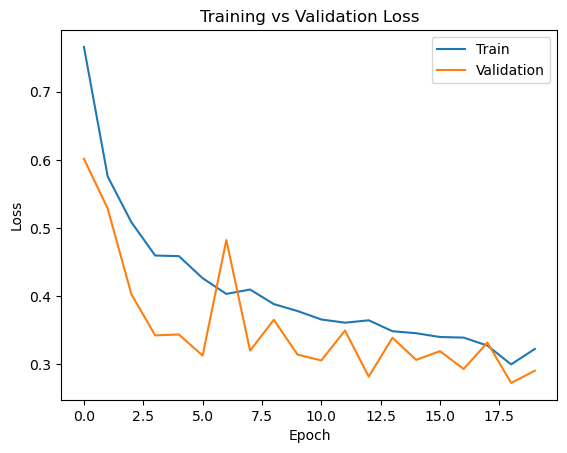

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

### Predictions

In [ ]:
y_pred=model.predict(X_test)

y_pred=np.argmax(y_pred,axis=1)

61/61 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step


### Confusion Matrix

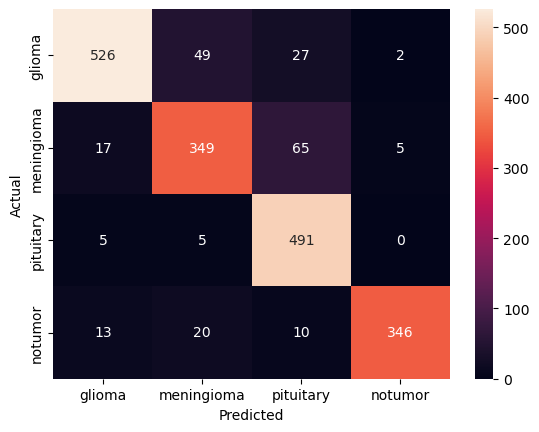

In [ ]:
cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',
xticklabels=CLASSES,
yticklabels=CLASSES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Report

In [ ]:
print(classification_report(y_test,y_pred,target_names=CLASSES))

              precision    recall  f1-score   support

      glioma       0.94      0.87      0.90       604
  meningioma       0.83      0.80      0.81       436
   pituitary       0.83      0.98      0.90       501
     notumor       0.98      0.89      0.93       389

    accuracy                           0.89      1930
   macro avg       0.89      0.89      0.89      1930
weighted avg       0.89      0.89      0.89      1930



### ROC Curve

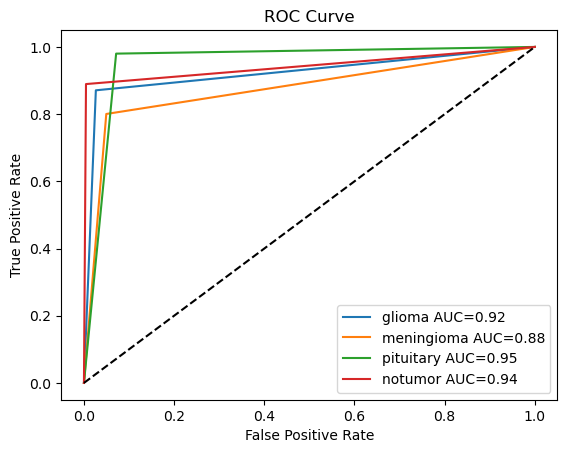

In [ ]:
y_test_bin=label_binarize(y_test,classes=[0,1,2,3])
y_pred_bin=label_binarize(y_pred,classes=[0,1,2,3])

for i in range(4):

    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_pred_bin[:,i])

    roc_auc=auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{CLASSES[i]} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

### Save Model

In [ ]:
model.save("brain_tumor_densenet121.h5")

NameError: name 'model' is not defined

### Predict Sample Image 

In [ ]:
import cv2
import os
import numpy as np

from tensorflow.keras.models import load_model

# When running this cell in isolation, re-define the class names used during training
CLASSES = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

# Load the saved model (adjust this path if you save it elsewhere)
model_path = r"C:\Brain_Tumor\brain_tumor_densenet121.h5"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")
model = load_model(model_path)

img_path = r"C:\Brain_Tumor\Epic and CSCR hospital Dataset\Test\glioma\G_702.jpg"
print(os.path.exists(img_path))
img=cv2.imread(img_path)

img=cv2.resize(img,(224,224))

img=img/255.0

img=np.expand_dims(img,axis=0)

prediction=model.predict(img)

class_index=np.argmax(prediction)

print("Predicted Class:",CLASSES[class_index])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


True
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: meningioma


In [ ]:
 #streamlit run streamlit_app.py